In [1]:
import pandas as pd

df = pd.read_csv("book_reviews_sample.csv")

print(df.head())
print(df.shape)
print(df.columns)

   index                                         reviewText  rating
0  11494  Clean and funny. A bit busy with all the diffe...       3
1    984  Alex a sexy hot cop and the PhD candidate. Wha...       4
2   1463  Good thing that this is a free story. I read i...       1
3  10342  Action, action, action! Equipment keeps gettin...       4
4   5256  this was hands down the worse book i have ever...       1
(100, 3)
Index(['index', 'reviewText', 'rating'], dtype='object')


In [2]:
def convert_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

df['label'] = df['rating'].apply(convert_sentiment)

In [11]:
print(df.columns)

Index(['text', 'label', 'clean_text'], dtype='object')


In [13]:
df.loc[:, 'clean_text'] = df['text'].apply(preprocess)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])

y = df['label']

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])

y = df['label']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression(max_iter=200)
nb = MultinomialNB()
dt = DecisionTreeClassifier()

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [23]:
dt = DecisionTreeClassifier(class_weight='balanced')
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [22]:
lr = LogisticRegression(max_iter=200, class_weight='balanced')
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [25]:
# Remove weak class
df = df[df['label'] != 'neutral']

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
y = df['label']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models
lr = LogisticRegression(max_iter=200, class_weight='balanced')
nb = MultinomialNB()
dt = DecisionTreeClassifier(class_weight='balanced')

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [26]:
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Decision Tree": dt
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))


 Logistic Regression
Accuracy: 0.7647058823529411
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75         8
    positive       0.78      0.78      0.78         9

    accuracy                           0.76        17
   macro avg       0.76      0.76      0.76        17
weighted avg       0.76      0.76      0.76        17

              precision    recall  f1-score   support

    negative       0.75      0.75      0.75         8
    positive       0.78      0.78      0.78         9

    accuracy                           0.76        17
   macro avg       0.76      0.76      0.76        17
weighted avg       0.76      0.76      0.76        17


 Naive Bayes
Accuracy: 0.6470588235294118
              precision    recall  f1-score   support

    negative       0.75      0.38      0.50         8
    positive       0.62      0.89      0.73         9

    accuracy                           0.65        17
   macro avg       0.68      0.63 

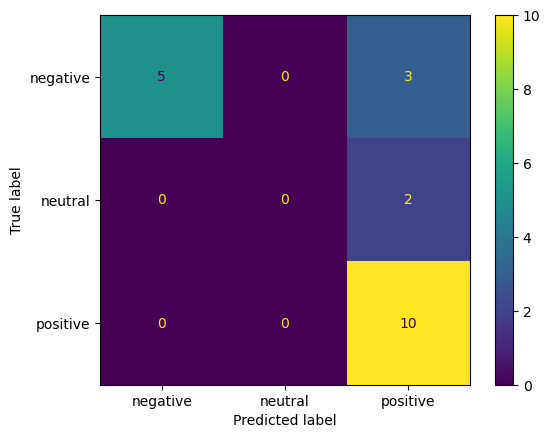

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()